In [2]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import entropy, skew, kurtosis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import warnings

In [3]:
def compute_histogram(image, bins=256):
    # Вычисление гистограммы
    hist = cv.calcHist([image], [0], None, [bins], [0, 256])
    hist = hist.flatten()
    
    # Вычисление центров бинов
    bin_width = 256 / bins
    bin_centers = np.array([i * bin_width + bin_width / 2 for i in range(bins)])
    hist_normalized = hist / np.sum(hist)
    
    # Взвешенные данные для статистики
    weighted_data = np.repeat(bin_centers, hist.astype(int))
    
    # Извлечение признаков
    features = {
        'mean': np.average(bin_centers, weights=hist),
        'variance': np.var(weighted_data) if len(weighted_data) > 0 else 0,
        'std_dev': np.std(weighted_data) if len(weighted_data) > 0 else 0,
        'skewness': skew(weighted_data) if len(weighted_data) > 0 else 0,
        'kurtosis': kurtosis(weighted_data) if len(weighted_data) > 0 else 0,
        'energy': np.sum(hist_normalized**2),
        'entropy': entropy(hist_normalized),
        'median': np.median(image),
        'percentile_25': np.percentile(image, 25),
        'percentile_75': np.percentile(image, 75),
        'min': np.min(image),
        'max': np.max(image),
        'contrast': np.max(image) - np.min(image)
    }
    
    return features, hist_normalized

In [4]:
image_folder = "C:\\KTH_TIPS\\"

texture_name = os.listdir(image_folder)[0]
texture_path = os.path.join(image_folder, texture_name)

image_files = [f for f in os.listdir(texture_path)]
image_path = os.path.join(texture_path, image_files[10])
image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

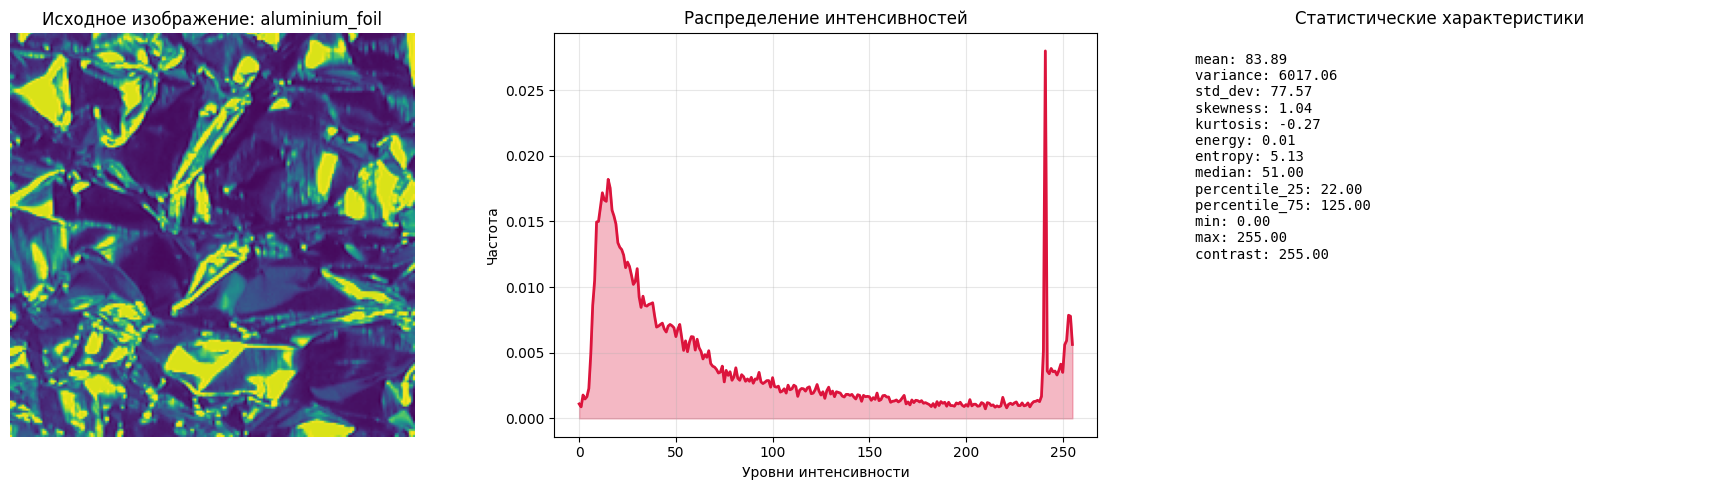

In [5]:
bins_count = 256
features, hist = compute_histogram(image, bins=bins_count)

# Создание графиков с другим размером
fig, (ax_img, ax_hist, ax_stats) = plt.subplots(1, 3, figsize=(18, 5))

ax_img.imshow(image, cmap='viridis')  
ax_img.set_title(f'Исходное изображение: {texture_name}')
ax_img.axis('off')

ax_hist.plot(range(bins_count), hist, color='crimson', linewidth=2)  
ax_hist.fill_between(range(bins_count), hist, alpha=0.3, color='crimson') 
ax_hist.set_title('Распределение интенсивностей')
ax_hist.set_xlabel('Уровни интенсивности')
ax_hist.set_ylabel('Частота')
ax_hist.grid(True, alpha=0.3)

# Отображение статистических характеристик
stats_text = '\n'.join([f'{k}: {v:.2f}' for k, v in features.items()])
ax_stats.text(0.05, 0.95, stats_text, transform=ax_stats.transAxes, 
              verticalalignment='top', fontsize=10, family='monospace')
ax_stats.set_title('Статистические характеристики')
ax_stats.axis('off')

ax_stats.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

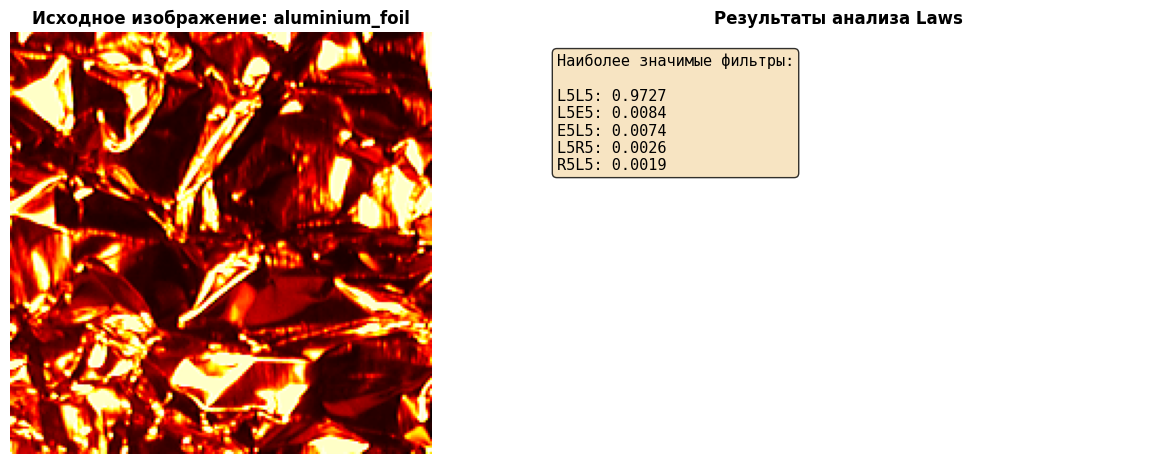

In [6]:
def laws_texture(image):
    # Определение одномерных ядер Laws
    kernels = [
        ([1, 4, 6, 4, 1], 'L5'),      # Level
        ([-1, -2, 0, 2, 1], 'E5'),    # Edge
        ([-1, 0, 2, 0, -1], 'S5'),    # Spot
        ([-1, 2, 0, -2, 1], 'W5'),    # Wave
        ([1, -4, 6, -4, 1], 'R5')     # Ripple
    ]
    
    features_dict = {}
    
    # Генерация двумерных ядер и вычисление энергии
    for k1, name1 in kernels:
        for k2, name2 in kernels:
            kernel_2d = np.outer(k1, k2)
            filtered = cv.filter2D(image.astype(np.float32), -1, kernel_2d)
            # Энергия как среднее квадратов отклика
            features_dict[f"{name1}{name2}"] = np.mean(filtered ** 2)
    
    # Нормализация признаков
    total_energy = sum(features_dict.values())
    if total_energy > 0:
        for key in features_dict:
            features_dict[key] /= total_energy
    
    return features_dict

# Вычисление характеристик Laws
features_dict = laws_texture(image)

fig, (ax_img, ax_stats) = plt.subplots(1, 2, figsize=(13, 5))

ax_img.imshow(image, cmap='hot')  # Изменена цветовая карта
ax_img.set_title(f'Исходное изображение: {texture_name}', fontsize=12, fontweight='bold')
ax_img.axis('off')

top_5 = sorted(features_dict.items(), key=lambda x: x[1], reverse=True)[:5]
stats_text = 'Наиболее значимые фильтры:\n\n' + '\n'.join([f'{k}: {v:.4f}' for k, v in top_5])

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax_stats.text(0.05, 0.95, stats_text, transform=ax_stats.transAxes, 
              verticalalignment='top', fontsize=11, family='monospace',
              bbox=props)
ax_stats.set_title('Результаты анализа Laws', fontsize=12, fontweight='bold')
ax_stats.axis('off')

plt.tight_layout(pad=2.0)
plt.show()

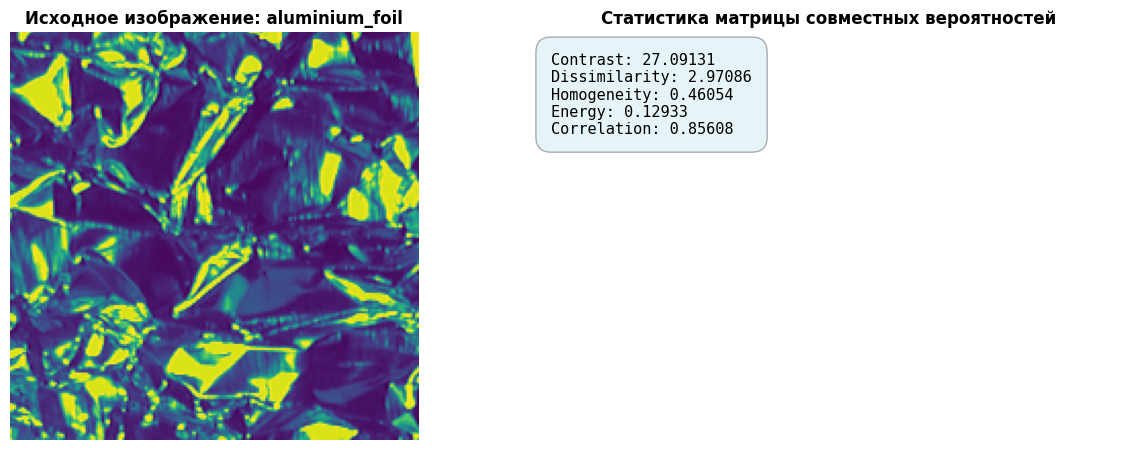

In [7]:
from skimage.feature import graycomatrix, graycoprops

def compute_glcm_features(image):
    # Параметры для вычисления GLCM
    distances = [1]
    angles = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
    
    # Квантование изображения для уменьшения вычислительной сложности
    image_quantized = (image // 8).astype(np.uint8)
    
    # Вычисление GLCM
    glcm = graycomatrix(
        image_quantized,
        distances=distances,
        angles=angles,
        levels=32,
        symmetric=True,
        normed=True
    )
    
    # Вычисление текстурных свойств
    properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    features = {}
    
    for prop in properties:
        feature_val = np.mean(graycoprops(glcm, prop))
        features[prop] = feature_val
    
    return features

# Вычисление характеристик GLCM
features = compute_glcm_features(image)

fig, (ax_img, ax_stats) = plt.subplots(1, 2, figsize=(13, 5))

# Отображение изображения
ax_img.imshow(image, cmap='viridis')  
ax_img.set_title(f'Исходное изображение: {texture_name}', fontsize=12, fontweight='bold')
ax_img.axis('off')

# Отображение характеристик GLCM
stats_text = '\n'.join([f'{k.capitalize()}: {v:.5f}' for k, v in features.items()])

props = dict(boxstyle='round', facecolor='lightblue', alpha=0.3, pad=1)
ax_stats.text(0.05, 0.95, stats_text, transform=ax_stats.transAxes,
              verticalalignment='top', fontsize=11, family='monospace',
              bbox=props)
ax_stats.set_title('Статистика матрицы совместных вероятностей', fontsize=12, fontweight='bold')
ax_stats.axis('off')

plt.tight_layout(pad=2.5)
plt.show()

In [8]:
def prepare_dataset(image_folder, feature_type, num_images=50):
    features = []
    labels = []
    
    for texture_name in os.listdir(image_folder):
        texture_path = os.path.join(image_folder, texture_name)
        if not os.path.isdir(texture_path):
            continue
        
        for image_file in os.listdir(texture_path)[:num_images]:
            image_path = os.path.join(texture_path, image_file)
            image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
            
            if image is not None:
                image = cv.resize(image, (128, 128))
                
                if feature_type == 'Histogram':
                    features_dict, _ = compute_histogram(image, 256)
                elif feature_type == 'Laws':
                    features_dict = laws_texture(image)
                else:  
                    features_dict = compute_glcm_features(image)
                
                features.append(list(features_dict.values()))
                labels.append(texture_name)
    
    return np.array(features), labels


def train_models(X, y):
    y_encoded = LabelEncoder().fit_transform(y)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    classifiers = {
        'KNN': KNeighborsClassifier(n_neighbors=3, n_jobs=-1),
        'SVM': SVC(kernel='rbf', random_state=42),
        'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=10)
    }
    
    models = {}
    for name, clf in classifiers.items():
        models[name] = clf.fit(X_train_scaled, y_train)
    
    return models, X_test_scaled, y_test, scaler

In [9]:
trained_models_dict = {}

feature_types = ['Histogram', 'Laws', 'GLCM']
for feature_type in feature_types:
    print("=" * 50)
    print(f" ОБРАБОТКА: {feature_type}")
    print("-" * 50)
    
    X, labels = prepare_dataset(image_folder, feature_type, 50)
    models, X_test, y_test, scaler = train_models(X, labels)
    
    trained_models_dict[feature_type] = {
        'models': models,
        'scaler': scaler
    }
    
    print(f"    Размер обучающих данных: {X.shape[0]} образцов × {X.shape[1]} признаков")
    print(f"    Тестовая выборка: {X_test.shape[0]} образцов")
    print()
    
    results_table = []
    for name, model in models.items():
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
            f1 = report['macro avg']['f1-score']
        
        results_table.append({
            'Модель': name,
            'Точность': accuracy,
            'F1-мера': f1
        })
        
    # Вывод результатов в виде таблицы
    for result in results_table:
        model_name = result['Модель'].ljust(15)
        acc_str = f"{result['Точность']:.3f}".rjust(6)
        f1_str = f"{result['F1-мера']:.3f}".rjust(6)
        print(f"   ├─ {model_name} | Точность: {acc_str} | F1-мера: {f1_str}")
    
    print()

 ОБРАБОТКА: Histogram
--------------------------------------------------
    Размер обучающих данных: 500 образцов × 13 признаков
    Тестовая выборка: 125 образцов

   ├─ KNN             | Точность:  0.872 | F1-мера:  0.875
   ├─ SVM             | Точность:  0.760 | F1-мера:  0.760
   ├─ DecisionTree    | Точность:  0.744 | F1-мера:  0.743

 ОБРАБОТКА: Laws
--------------------------------------------------
    Размер обучающих данных: 500 образцов × 25 признаков
    Тестовая выборка: 125 образцов

   ├─ KNN             | Точность:  0.824 | F1-мера:  0.826
   ├─ SVM             | Точность:  0.536 | F1-мера:  0.520
   ├─ DecisionTree    | Точность:  0.688 | F1-мера:  0.687

 ОБРАБОТКА: GLCM
--------------------------------------------------
    Размер обучающих данных: 500 образцов × 5 признаков
    Тестовая выборка: 125 образцов

   ├─ KNN             | Точность:  0.704 | F1-мера:  0.704
   ├─ SVM             | Точность:  0.544 | F1-мера:  0.546
   ├─ DecisionTree    | Точность:  0.62

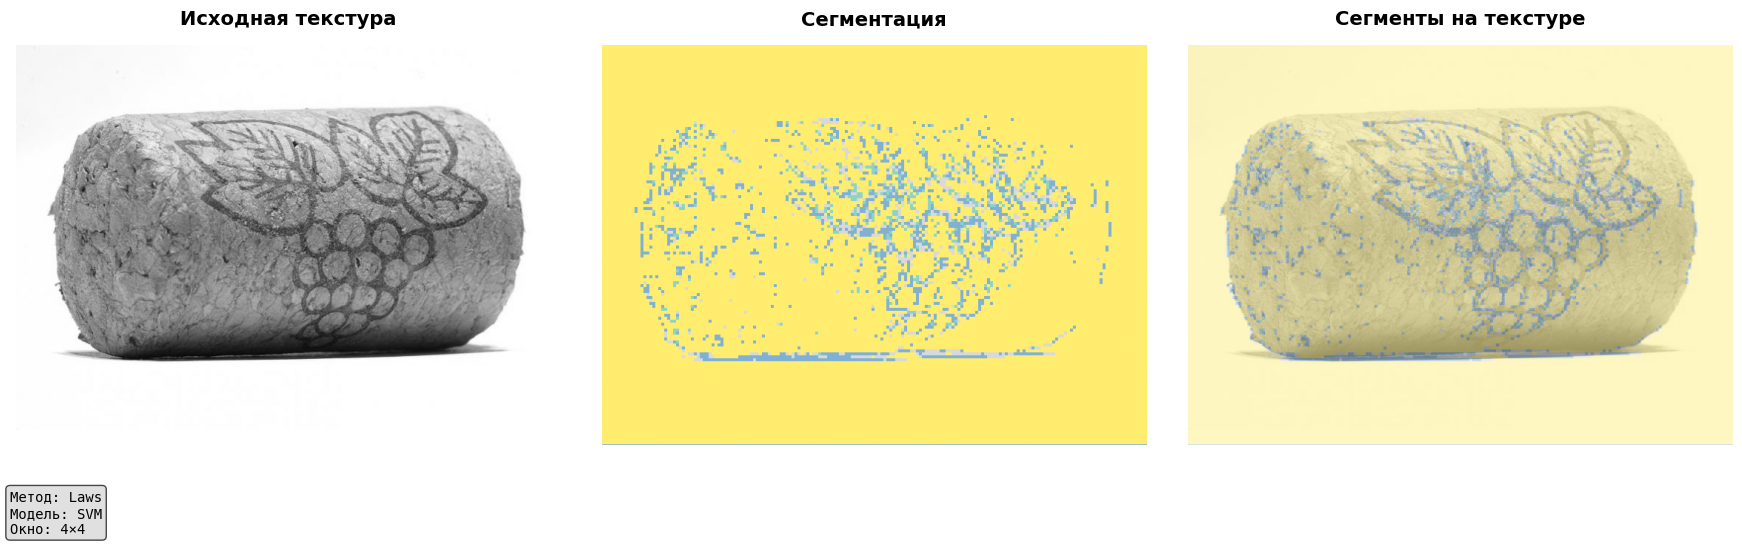

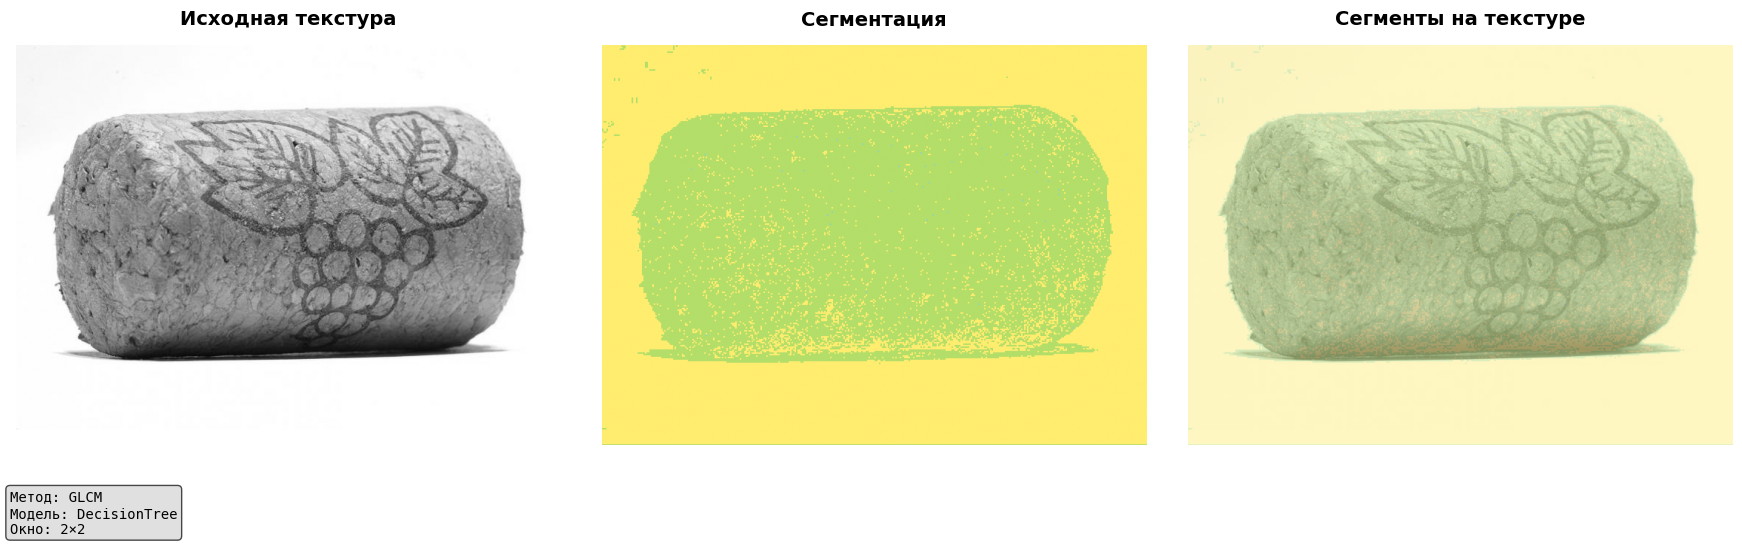

In [10]:
def texture_segmentation(image_path, trained_models_dict, feature_type, model_name, 
                         window_size=32, step=None, n_classes=4):
    original_image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    
    if step is None:
        step = window_size
    
    models = trained_models_dict[feature_type]['models']
    scaler = trained_models_dict[feature_type]['scaler']
    model = models[model_name]
    
    h, w = original_image.shape
    temp_seg_map = np.zeros((h, w), dtype=np.uint8)
    all_predictions = []
    
    feature_extractors = {
        'Histogram': lambda img: list(compute_histogram(img, 32)[0].values()),
        'Laws': lambda img: list(laws_texture(img).values()),
        'GLCM': lambda img: list(compute_glcm_features(img).values())
    }
    
    for y in range(0, h - window_size + 1, step):
        for x in range(0, w - window_size + 1, step):
            window = original_image[y:y+window_size, x:x+window_size]
            
            features = feature_extractors[feature_type](window)
            features_scaled = scaler.transform([features])
            prediction = model.predict(features_scaled)[0]
            
            temp_seg_map[y:y+window_size, x:x+window_size] = prediction
            all_predictions.append(prediction)
    
    unique, counts = np.unique(all_predictions, return_counts=True)
    top_classes = unique[np.argsort(counts)[-n_classes:]]
    
    segmentation_map = np.zeros_like(temp_seg_map)
    
    for new_class, old_class in enumerate(top_classes):
        segmentation_map[temp_seg_map == old_class] = new_class
    
    mask_not_top = ~np.isin(temp_seg_map, top_classes)
    if np.any(mask_not_top):
        segmentation_map[mask_not_top] = 1  
    
    return segmentation_map, original_image

def show_segment(image_path, trained_models_dict, **kwargs):
    seg_map, original = texture_segmentation(image_path, trained_models_dict, **kwargs)
    

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    ax1.imshow(original, cmap='gist_gray')
    ax1.set_title('Исходная текстура', fontsize=14, fontweight='bold', pad=15)
    ax1.axis('off')
    
    ax2.imshow(seg_map, cmap='Set3')
    ax2.set_title('Сегментация', fontsize=14, fontweight='bold', pad=15)
    ax2.axis('off')
    
    ax3.imshow(seg_map, cmap='Set3', alpha=0.7)
    ax3.imshow(original, cmap='gist_gray', alpha=0.4)
    ax3.set_title('Сегменты на текстуре', fontsize=14, fontweight='bold', pad=15)
    ax3.axis('off')
    

    params_text = f"Метод: {kwargs.get('feature_type', 'N/A')}\n"
    params_text += f"Модель: {kwargs.get('model_name', 'N/A')}\n"
    params_text += f"Окно: {kwargs.get('window_size', 'N/A')}×{kwargs.get('window_size', 'N/A')}"
    
    plt.figtext(0.02, 0.02, params_text, fontsize=10, 
                family='monospace', bbox=dict(boxstyle="round", facecolor="lightgray", alpha=0.7))
    
    plt.tight_layout(pad=3.0)
    plt.show()

show_segment("choto.jpg", trained_models_dict, 
             window_size=4, feature_type='Laws', model_name='SVM')

show_segment("choto.jpg", trained_models_dict, 
             window_size=2, feature_type='GLCM', model_name='DecisionTree')

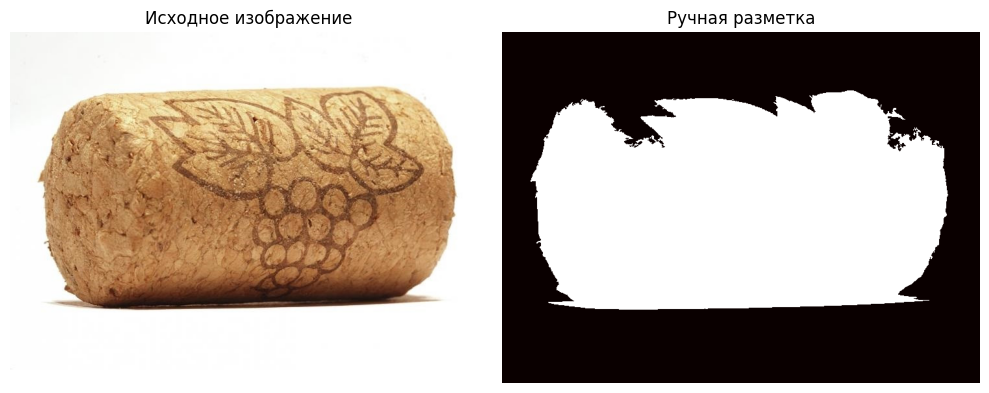

In [14]:

import matplotlib.pyplot as plt
def manual_segment(image):
    image_gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    _, mask = cv.threshold(image_gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    
    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(mask)
    
    if contours:
        largest_contour = max(contours, key=cv.contourArea)
        cv.drawContours(final_mask, [largest_contour], 0, 1, -1)
    
    return final_mask


def remap_classes(mask, n_classes):
    unique, counts = np.unique(mask, return_counts=True)
    top_classes = unique[np.argsort(-counts)[:n_classes]]
    
    result = np.zeros_like(mask)
    for new_id, old_id in enumerate(top_classes):
        result[mask == old_id] = new_id
    
    return result
image_path = "choto.jpg"
image = cv.imread(image_path)
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

manual_mask = manual_segment(image_rgb)
manual_mask = remap_classes(manual_mask, 4)
fig, (ax_orig, ax_segment) = plt.subplots(1, 2, figsize=(10, 5))

ax_orig.imshow(image_rgb)
ax_orig.set_title('Исходное изображение')
ax_orig.axis('off')

ax_segment.imshow(manual_mask, cmap='hot')
ax_segment.set_title('Ручная разметка')
ax_segment.axis('off')

plt.tight_layout()
plt.show()

Анализ сегментации
Метод: GLCM
Алгоритм: DecisionTree
──────────────────────────────


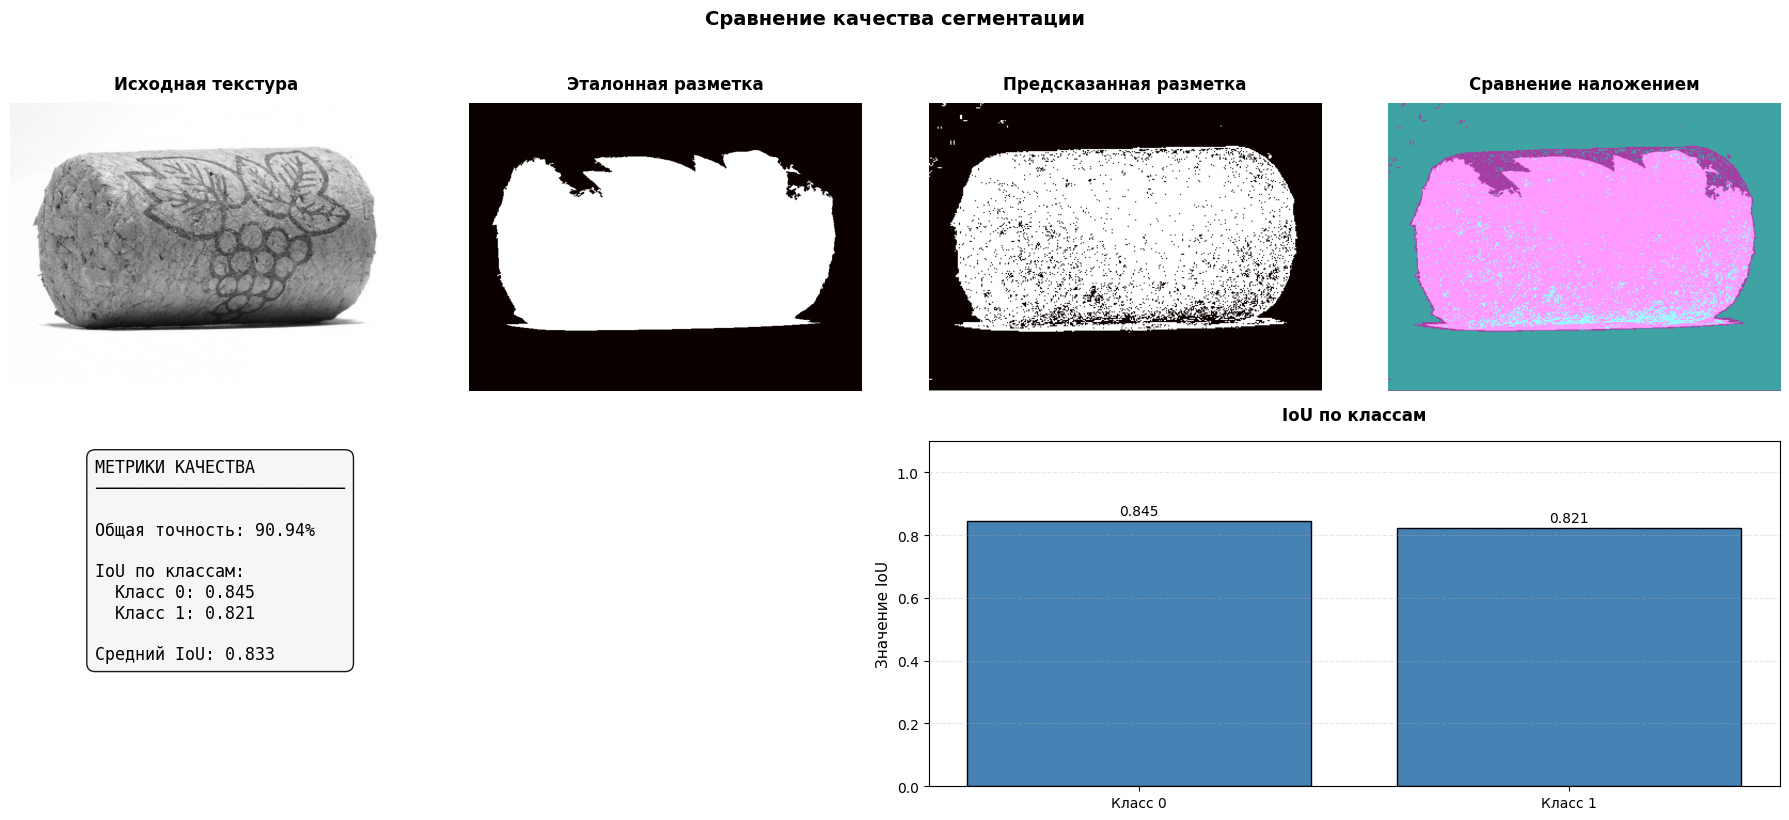

In [18]:
from sklearn.metrics import accuracy_score, jaccard_score

def find_best_mapping(true_mask, pred_mask):
    true_flat = true_mask.flatten()
    pred_flat = pred_mask.flatten()
    
    true_classes = np.unique(true_flat)
    pred_classes = np.unique(pred_flat)
    
    mapping = {}
    for pred_class in pred_classes:
        best_true_class = None
        best_overlap = -1
        
        for true_class in true_classes:
            overlap = np.sum((true_flat == true_class) & (pred_flat == pred_class))
            if overlap > best_overlap:
                best_overlap = overlap
                best_true_class = true_class
        
        mapping[pred_class] = best_true_class
    
    return mapping


def compare_segmentation(manual_mask, predicted_mask, original_img):
    if manual_mask.shape != predicted_mask.shape:
        predicted_mask = cv.resize(predicted_mask, 
                                   (manual_mask.shape[1], manual_mask.shape[0]))
    
    mapping = find_best_mapping(manual_mask, predicted_mask)
    pred_mapped = np.zeros_like(predicted_mask)
    
    for pred_class, true_class in mapping.items():
        pred_mapped[predicted_mask == pred_class] = true_class
    
    accuracy = accuracy_score(manual_mask.flatten(), pred_mapped.flatten())
    iou_scores = jaccard_score(manual_mask.flatten(), pred_mapped.flatten(),
                              average=None, labels=np.unique(manual_mask))
    
    # Создаем фигуру
    fig = plt.figure(figsize=(18, 8))
    
    # 1. Исходное изображение
    ax1 = plt.subplot(2, 4, 1)
    ax1.imshow(original_img, cmap='gray')
    ax1.set_title('Исходная текстура', fontsize=12, fontweight='bold', pad=10)
    ax1.axis('off')
    
    # 2. Ручная разметка
    ax2 = plt.subplot(2, 4, 2)
    ax2.imshow(manual_mask, cmap='hot')
    ax2.set_title('Эталонная разметка', fontsize=12, fontweight='bold', pad=10)
    ax2.axis('off')
    
    # 3. Предсказанная разметка
    ax3 = plt.subplot(2, 4, 3)
    ax3.imshow(pred_mapped, cmap='hot')
    ax3.set_title('Предсказанная разметка', fontsize=12, fontweight='bold', pad=10)
    ax3.axis('off')
    
    # 4. Наложение
    ax4 = plt.subplot(2, 4, 4)
    ax4.imshow(manual_mask, cmap='hot', alpha=0.6)
    ax4.imshow(pred_mapped, cmap='cool', alpha=0.4)
    ax4.set_title('Сравнение наложением', fontsize=12, fontweight='bold', pad=10)
    ax4.axis('off')
    
    # 5. Метрики качества
    ax5 = plt.subplot(2, 4, (5, 6))
    ax5.axis('off')
    
    results_text = "МЕТРИКИ КАЧЕСТВА\n"
    results_text += "─" * 25 + "\n\n"
    results_text += f"Общая точность: {accuracy:.2%}\n\n"
    results_text += "IoU по классам:\n"
    
    for i, class_id in enumerate(np.unique(manual_mask)):
        score = iou_scores[i]
        results_text += f"  Класс {class_id}: {score:.3f}\n"
    
    # Добавляем общую оценку
    mean_iou = np.mean(iou_scores)
    results_text += f"\nСредний IoU: {mean_iou:.3f}"
    
    ax5.text(0.1, 0.95, results_text, transform=ax5.transAxes,
             verticalalignment='top', fontsize=12, family='monospace',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="whitesmoke", alpha=0.9))
    
    # 6. График IoU
    ax6 = plt.subplot(2, 4, (7, 8))
    classes = [f'Класс {i}' for i in range(len(iou_scores))]
    
    bars = ax6.bar(classes, iou_scores, color='steelblue', edgecolor='black', linewidth=1)
    
    for bar, score in zip(bars, iou_scores):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{score:.3f}', ha='center', va='bottom', fontsize=10)
    
    ax6.set_title('IoU по классам', fontsize=12, fontweight='bold', pad=15)
    ax6.set_ylabel('Значение IoU', fontsize=11)
    ax6.set_ylim(0, 1.1)
    ax6.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    plt.suptitle(f'Сравнение качества сегментации', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()

feature_type = 'GLCM'
model_name = 'DecisionTree'

print(f"Анализ сегментации")
print(f"Метод: {feature_type}")
print(f"Алгоритм: {model_name}")
print("─" * 30)

predicted_mask, _ = texture_segmentation(
    image_path,
    trained_models_dict,
    window_size=2,
    feature_type=feature_type,
    model_name=model_name
)

image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
compare_segmentation(manual_mask, predicted_mask, image)